In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from tqdm import trange
import matplotlib.ticker as ticker

#DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../18-finalize/processed-data/"
#DATA_PATH3 = "../../18-Y2H-data/processed-data/"
#ABUNDANCE  = "../../0-download-inputs/data-files/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "Arial",
    #"font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [2]:
# load the datasets with node centrality information and get nodes in both
nodes = pd.read_pickle(f"{DATA_PATH2}20260210-s288c-ANnnotated-Yeast-Interactome.pkl")

Remove proteins with low plddt, are membrane proteins and/or signal peptide

In [3]:
# Filter nodes to remove proteins with low pLDDT and/or are membrane proteins (TM) with/without signal peptide (SP)
filtered_nodes = nodes[
    (nodes['mean_plddt'] >= 70) &
    (~nodes['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()

# Print stats to for nodes
print(f"Original rows: {len(nodes)}")
print(f"Filtered rows: {len(filtered_nodes)}")

Original rows: 3927
Filtered rows: 2466


In [4]:
# determine which nodes are hubs based on percentile cutoff for degree centrality
cut = 0.10

y2h_threshold = filtered_nodes['Y2H_degree_centrality'].quantile(1 - cut)
y2h_hubs      = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] >= y2h_threshold]
y2h_nothub    = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] <  y2h_threshold]

print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in Y2H data is 0.00297; there are 116 hubs and 866 non hubs


## Supplement Fig 3A-D

*Create boxplots of stability metrices and melting point for hubs and non-hubs in Y2H dataset

In [5]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid large memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

def clean_values(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()

# Only remove inf/nan — DO NOT require > 0
y2h_nothub_vals = y2h_nothub["Ghosh-Dill-dG"]
y2h_hub_vals    = y2h_hubs["Ghosh-Dill-dG"]

# Groups: (label, data, color)
groups = [
    ("Y2H hubs",     y2h_hub_vals,    Y2H_COLOR),
    ("Y2H non-hubs", y2h_nothub_vals, Y2H_COLOR),
]

# Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:12<00:00, 79436.99it/s]


Y2H hubs: median=-11.10, 95% CI=(-12.20, -10.27), n=116)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:21<00:00, 46049.72it/s]

Y2H non-hubs: median=-9.84, 95% CI=(-10.23, -9.58), n=866)


In [6]:
# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on Ghosh-Dill-dG ===")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="greater")

print("=== Mann–Whitney U tests on Ghosh-Dill-dG ===")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

=== Mann–Whitney U tests on Ghosh-Dill-dG ===

Y2H hubs vs Y2H non-hubs
n(hubs) = 116, n(non-hubs) = 866
median(hubs) = -11.10, median(non-hubs) = -9.84
U = 42277.50, p = 0.005582
=== Mann–Whitney U tests on Ghosh-Dill-dG ===

Y2H hubs vs Y2H non-hubs
n(hubs) = 116, n(non-hubs) = 866
median(hubs) = -11.10, median(non-hubs) = -9.84
U = 42277.50, p = 0.9972


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_31870/900770616.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


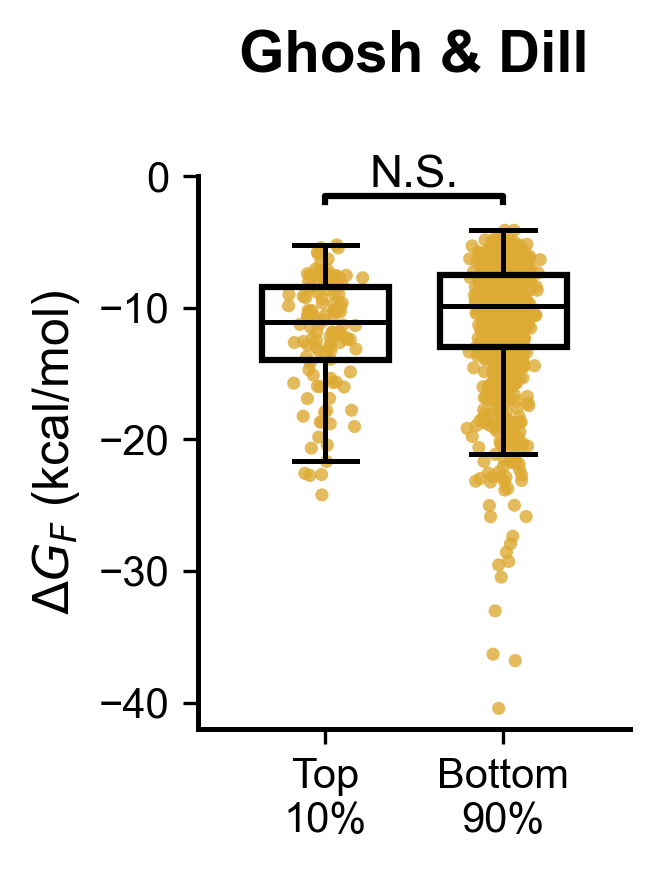

In [7]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 0.5
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals = [y2h_hub_vals, y2h_nothub_vals]
group_colors = ["#DDAA33", "#DDAA33"]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Top\n10%", "Bottom\n90%"],
    positions=[1, 1.7],   
    widths=0.5,             
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel(r"$\Delta G_F$ (kcal/mol)", fontsize=12)
ax.set_title("Ghosh & Dill", fontweight='bold')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(y2h_hub_vals.min(), y2h_nothub_vals.min())
y_max = max(y2h_hub_vals.max(), y2h_nothub_vals.max())

# Place significance bracket at a fixed, nice height just above 0
bracket_y = -2  # you can adjust: -1, -3, -5 depending on taste
ax.set_ylim(-42, 0)
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")


# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

# Y2H under boxes 3–4
#ax.plot(
#    [1.0, 1.7], [-0.16, -0.16],
#    transform=trans,
#    clip_on=False,
#    color=Y2H_COLOR,
#    lw=1.5,
#)
#ax.text(
#    1.3, -0.20, "Y2H",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=Y2H_COLOR,
#)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("Supp3-B.svg")
plt.show()

In [8]:
# multiply cagiada-dG by -1
y2h_hubs["cagiada-dG"]    = -y2h_hubs["cagiada-dG"]
y2h_nothub["cagiada-dG"]  = -y2h_nothub["cagiada-dG"]

# Only remove inf/nan — DO NOT require > 0
y2h_nothub_vals = y2h_nothub["cagiada-dG"]
y2h_hub_vals    = y2h_hubs["cagiada-dG"]

# Groups: (label, data, color)
groups = [
    ("Y2H hubs",     y2h_hub_vals,    Y2H_COLOR),
    ("Y2H non-hubs", y2h_nothub_vals, Y2H_COLOR),
]

# Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_31870/1052649257.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y2h_hubs["cagiada-dG"]    = -y2h_hubs["cagiada-dG"]
/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_31870/1052649257.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y2h_nothub["cagiada-dG"]  = -y2h_nothub["cagiada-dG"]
Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:12<00:00, 80235.47it/s]


Y2H hubs: median=-19.32, 95% CI=(-21.09, -17.56), n=116)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:21<00:00, 45528.65it/s]

Y2H non-hubs: median=-18.07, 95% CI=(-19.19, -16.62), n=866)


In [9]:
# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on cagiada-dG ===")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="greater")

print("=== Mann–Whitney U tests on cagiada-dG ===")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

=== Mann–Whitney U tests on cagiada-dG ===

Y2H hubs vs Y2H non-hubs
n(hubs) = 116, n(non-hubs) = 866
median(hubs) = -19.32, median(non-hubs) = -18.07
U = 45055.00, p = 0.07137
=== Mann–Whitney U tests on cagiada-dG ===

Y2H hubs vs Y2H non-hubs
n(hubs) = 116, n(non-hubs) = 866
median(hubs) = -19.32, median(non-hubs) = -18.07
U = 45055.00, p = 0.9643


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_31870/2112074040.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


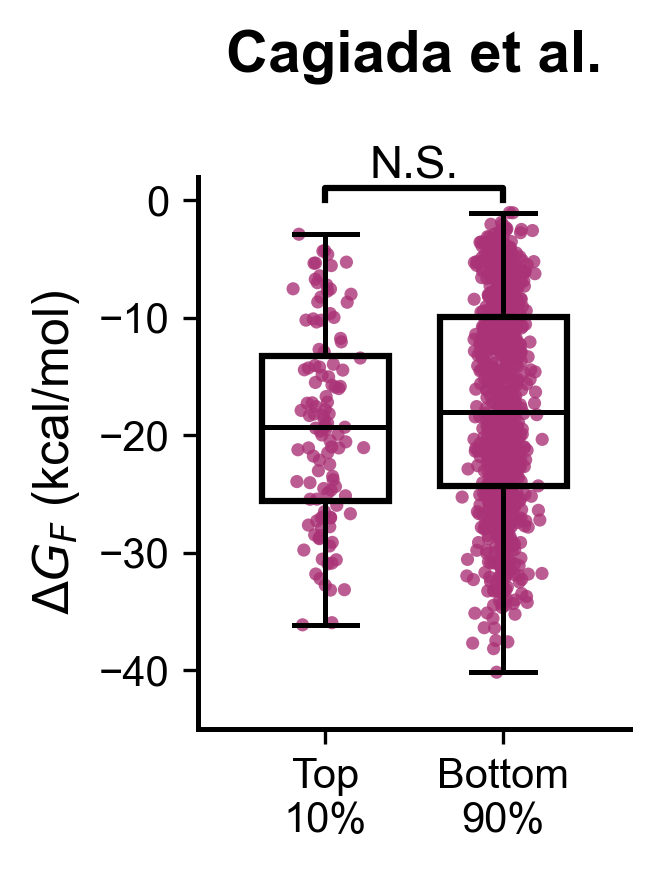

In [10]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals = [y2h_hub_vals, y2h_nothub_vals]
group_colors = ['#AA3377',    '#AA3377']

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Top\n10%", "Bottom\n90%"],
    positions=[1, 1.7],   
    widths=0.5,             
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel(r"$\Delta G_F$ (kcal/mol)", fontsize=12)
ax.set_title("Cagiada et al.", fontweight='bold')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(y2h_hub_vals.min(), y2h_nothub_vals.min())
y_max = 10
ax.set_ylim(-45, 2)   # 5% padding at bottom, 0 at top

# Place significance bracket at a fixed, nice height just above 0
bracket_y = 0  # you can adjust: -1, -3, -5 depending on taste
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")


# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

#ax.plot(
#    [1.0, 1.7], [-0.16, -0.16],
#    transform=trans,
#    clip_on=False,
#    color=Y2H_COLOR,
#    lw=1.5,
#)
#ax.text(
#    1.3, -0.20, "Y2H",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=Y2H_COLOR,
#)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("Supp3-C.svg")
plt.show()

In [11]:
# Only remove inf/nan — DO NOT require > 0
y2h_nothub_vals = y2h_nothub["Rosetta_best_total_score"]
y2h_hub_vals    = y2h_hubs["Rosetta_best_total_score"]

# Groups: (label, data, color)
groups = [
    ("Y2H hubs",     y2h_hub_vals,    Y2H_COLOR),
    ("Y2H non-hubs", y2h_nothub_vals, Y2H_COLOR),
]

# Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:12<00:00, 79120.49it/s]


Y2H hubs: median=-1101.80, 95% CI=(-1245.16, -987.83), n=116)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:21<00:00, 45715.89it/s]

Y2H non-hubs: median=-996.05, 95% CI=(-1059.33, -957.19), n=866)


In [12]:
# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on Rosetta_best_total_score ===")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="greater")

print("=== Mann–Whitney U tests on Rosetta_best_total_score ===")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

=== Mann–Whitney U tests on Rosetta_best_total_score ===

Y2H hubs vs Y2H non-hubs
n(hubs) = 116, n(non-hubs) = 866
median(hubs) = -1101.80, median(non-hubs) = -996.05
U = 44044.00, p = 0.03112
=== Mann–Whitney U tests on Rosetta_best_total_score ===

Y2H hubs vs Y2H non-hubs
n(hubs) = 116, n(non-hubs) = 866
median(hubs) = -1101.80, median(non-hubs) = -996.05
U = 44044.00, p = 0.9845


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_31870/3538766153.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


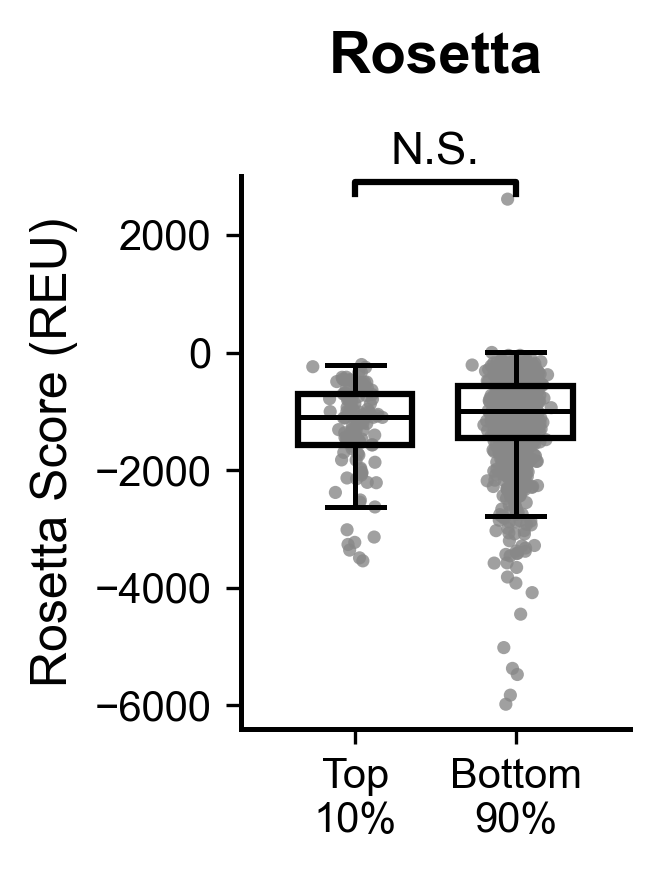

In [13]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 200
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals = [y2h_hub_vals, y2h_nothub_vals]
group_colors = ['#888888',    '#888888']

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Top\n10%", "Bottom\n90%"],
    positions=[1, 1.7],   
    widths=0.5,             
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel("Rosetta Score (REU)", fontsize=12)
ax.set_title("Rosetta", fontweight='bold')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(y2h_hub_vals.min(), y2h_nothub_vals.min())
y_max = max(y2h_hub_vals.max(), y2h_nothub_vals.max())
ax.set_ylim(-6400, 3000)

# Place significance bracket at a fixed, nice height just above 0
bracket_y = 2700  # you can adjust: -1, -3, -5 depending on taste
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")


# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

# Y2H under boxes 3–4
#ax.plot(
#    [1.0, 1.7], [-0.16, -0.16],
#    transform=trans,
#    clip_on=False,
#    color=Y2H_COLOR,
#    lw=1.5,
#)
#ax.text(
#    1.3, -0.20, "Y2H",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=Y2H_COLOR,
#)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("Supp3-A.svg")
plt.show()

In [14]:
# Only remove inf/nan — DO NOT require > 0
y2h_hub_vals = y2h_hubs[y2h_hubs['meltome-fit-R2'] > 0.9]["meltome-melting-point"]\
    .replace([np.inf, -np.inf], np.nan).dropna()

y2h_nothub_vals = y2h_nothub[y2h_nothub['meltome-fit-R2'] > 0.9]["meltome-melting-point"]\
    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Y2H hubs",     y2h_hub_vals,    Y2H_COLOR),
    ("Y2H non-hubs", y2h_nothub_vals, Y2H_COLOR),
]

# Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:13<00:00, 71626.18it/s]


Y2H hubs: median=49.66, 95% CI=(48.47, 50.20), n=62)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:16<00:00, 59542.97it/s]

Y2H non-hubs: median=49.75, 95% CI=(49.45, 50.00), n=452)


In [15]:
# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on meltome-melting-point ===")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="greater")

print("=== Mann–Whitney U tests on meltome-melting-point ===")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

=== Mann–Whitney U tests on meltome-melting-point ===

Y2H hubs vs Y2H non-hubs
n(hubs) = 62, n(non-hubs) = 452
median(hubs) = 49.66, median(non-hubs) = 49.75
U = 13970.00, p = 0.9698
=== Mann–Whitney U tests on meltome-melting-point ===

Y2H hubs vs Y2H non-hubs
n(hubs) = 62, n(non-hubs) = 452
median(hubs) = 49.66, median(non-hubs) = 49.75
U = 13970.00, p = 0.5155


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_31870/2082142231.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


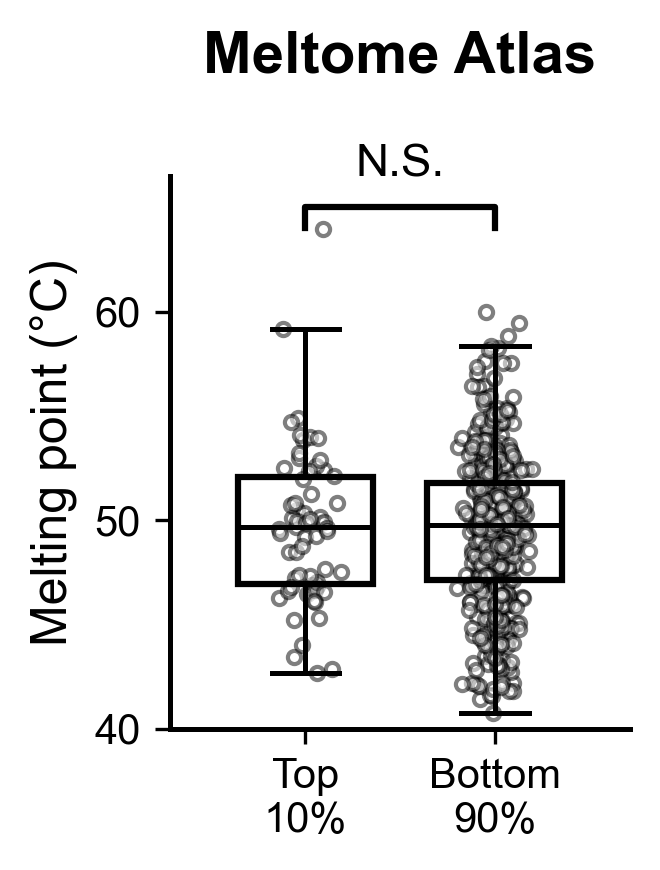

In [16]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top + 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals = [y2h_hub_vals, y2h_nothub_vals]
group_colors = ['white',    'white']

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        facecolor="white",   # inside color
        edgecolor="black",
        alpha=0.5,
        color=color,
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Top\n10%", "Bottom\n90%"],
    positions=[1, 1.7],   
    widths=0.5,             
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel("Melting point (°C)", fontsize=12)
ax.set_title("Meltome Atlas", fontweight='bold')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = 40     # a little below the real minimum
y_max = 66.5     # enough headroom for the bracket
ax.set_ylim(y_min, y_max)
ax.set_yticks([40, 50, 60])          # ← forces exactly these ticks
ax.set_yticklabels([40, 50, 60])

# Place significance bracket at a fixed, nice height just above 0
bracket_y = 64
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")


# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

# Y2H under boxes 3–4
#ax.plot(
#    [1.0, 1.7], [-0.16, -0.16],
#    transform=trans,
#    clip_on=False,
#    color=Y2H_COLOR,
#    lw=1.5,
#)
#ax.text(
#    1.3, -0.20, "Y2H",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=Y2H_COLOR,
#)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("Supp3-D.svg")
plt.show()

## Supplemt Figure 3E-F
* Create boxplots of stability metrices and melting point for bottlenecks and non-bottlenecks in Y2H dataset

In [17]:
# determine which nodes are hubs based on percentile cutoff for betweenness centrality
cut = 0.10

y2h_threshold = filtered_nodes['Y2H_betweenness_centrality'].quantile(1 - cut)
y2h_hubs      = filtered_nodes[filtered_nodes['Y2H_betweenness_centrality'] >= y2h_threshold]
y2h_nothub    = filtered_nodes[filtered_nodes['Y2H_betweenness_centrality'] <  y2h_threshold]

print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in Y2H data is 0.00399; there are 99 hubs and 883 non hubs


In [18]:
# Only remove inf/nan — DO NOT require > 0
y2h_nothub_vals = y2h_nothub["Ghosh-Dill-dG"]
y2h_hub_vals    = y2h_hubs["Ghosh-Dill-dG"]

# Groups: (label, data, color)
groups = [
    ("Y2H hubs",     y2h_hub_vals,    Y2H_COLOR),
    ("Y2H non-hubs", y2h_nothub_vals, Y2H_COLOR),
]

# Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:12<00:00, 81559.46it/s]


Y2H hubs: median=-11.06, 95% CI=(-11.86, -9.85), n=99)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:22<00:00, 45284.73it/s]

Y2H non-hubs: median=-9.97, 95% CI=(-10.31, -9.64), n=883)


In [19]:
# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on Ghosh-Dill-dG ===")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="greater")

print("=== Mann–Whitney U tests on Ghosh-Dill-dG ===")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

=== Mann–Whitney U tests on Ghosh-Dill-dG ===

Y2H hubs vs Y2H non-hubs
n(hubs) = 99, n(non-hubs) = 883
median(hubs) = -11.06, median(non-hubs) = -9.97
U = 40985.50, p = 0.309
=== Mann–Whitney U tests on Ghosh-Dill-dG ===

Y2H hubs vs Y2H non-hubs
n(hubs) = 99, n(non-hubs) = 883
median(hubs) = -11.06, median(non-hubs) = -9.97
U = 40985.50, p = 0.8456


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_31870/707839090.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


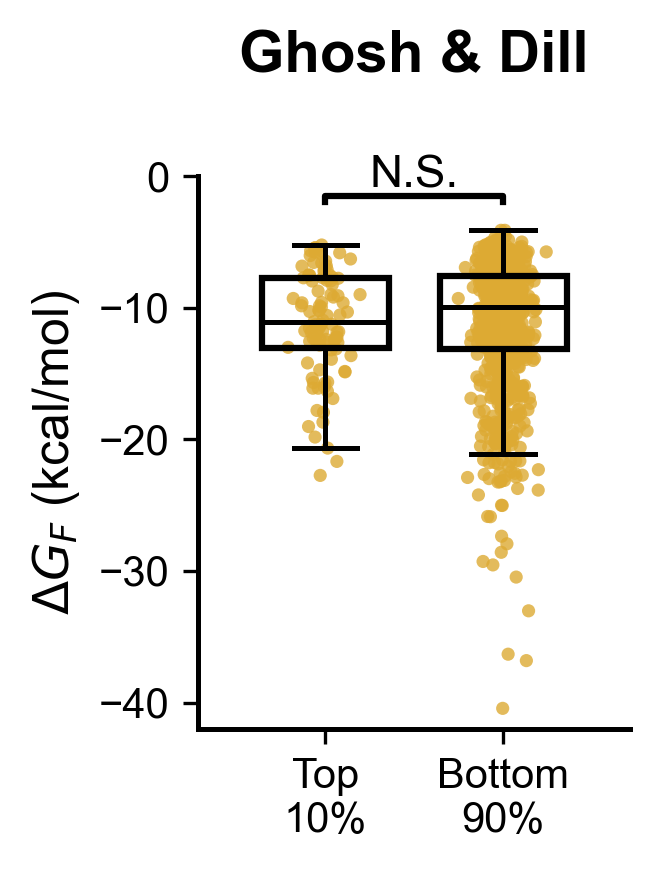

In [20]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 0.5
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals = [y2h_hub_vals, y2h_nothub_vals]
group_colors = ["#DDAA33", "#DDAA33"]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Top\n10%", "Bottom\n90%"],
    positions=[1, 1.7],   
    widths=0.5,             
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel(r"$\Delta G_F$ (kcal/mol)", fontsize=12)
ax.set_title("Ghosh & Dill", fontweight='bold')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(y2h_hub_vals.min(), y2h_nothub_vals.min())
y_max = max(y2h_hub_vals.max(), y2h_nothub_vals.max())
ax.set_ylim(y_min * 1.05, y_max)   # 5% padding at bottom, 0 at top

# Place significance bracket at a fixed, nice height just above 0
bracket_y = -2  # you can adjust: -1, -3, -5 depending on taste
ax.set_ylim(-42, 0)
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")


# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

# Y2H under boxes 3–4
#ax.plot(
#    [1.0, 1.7], [-0.16, -0.16],
#    transform=trans,
#    clip_on=False,
#    color=Y2H_COLOR,
#    lw=1.5,
#)
#ax.text(
#    1.3, -0.20, "Y2H",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=Y2H_COLOR,
#)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("Supp3-F.svg")
plt.show()

In [21]:
# multiply cagiada-dG by -1
y2h_hubs["cagiada-dG"]    = -y2h_hubs["cagiada-dG"]
y2h_nothub["cagiada-dG"]  = -y2h_nothub["cagiada-dG"]

# Only remove inf/nan — DO NOT require > 0
y2h_nothub_vals = y2h_nothub["cagiada-dG"]
y2h_hub_vals    = y2h_hubs["cagiada-dG"]

# Groups: (label, data, color)
groups = [
    ("Y2H hubs",     y2h_hub_vals,    Y2H_COLOR),
    ("Y2H non-hubs", y2h_nothub_vals, Y2H_COLOR),
]

# Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_31870/1052649257.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y2h_hubs["cagiada-dG"]    = -y2h_hubs["cagiada-dG"]
/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_31870/1052649257.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y2h_nothub["cagiada-dG"]  = -y2h_nothub["cagiada-dG"]
Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:12<00:00, 81431.84it/s]


Y2H hubs: median=-18.14, 95% CI=(-19.99, -15.52), n=99)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:22<00:00, 45395.39it/s]

Y2H non-hubs: median=-18.26, 95% CI=(-19.38, -16.94), n=883)


In [22]:
# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on cagiada-dG ===")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="greater")

print("=== Mann–Whitney U tests on cagiada-dG ===")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

=== Mann–Whitney U tests on cagiada-dG ===

Y2H hubs vs Y2H non-hubs
n(hubs) = 99, n(non-hubs) = 883
median(hubs) = -18.14, median(non-hubs) = -18.26
U = 44635.00, p = 0.7293
=== Mann–Whitney U tests on cagiada-dG ===

Y2H hubs vs Y2H non-hubs
n(hubs) = 99, n(non-hubs) = 883
median(hubs) = -18.14, median(non-hubs) = -18.26
U = 44635.00, p = 0.3647


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_31870/4156043853.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


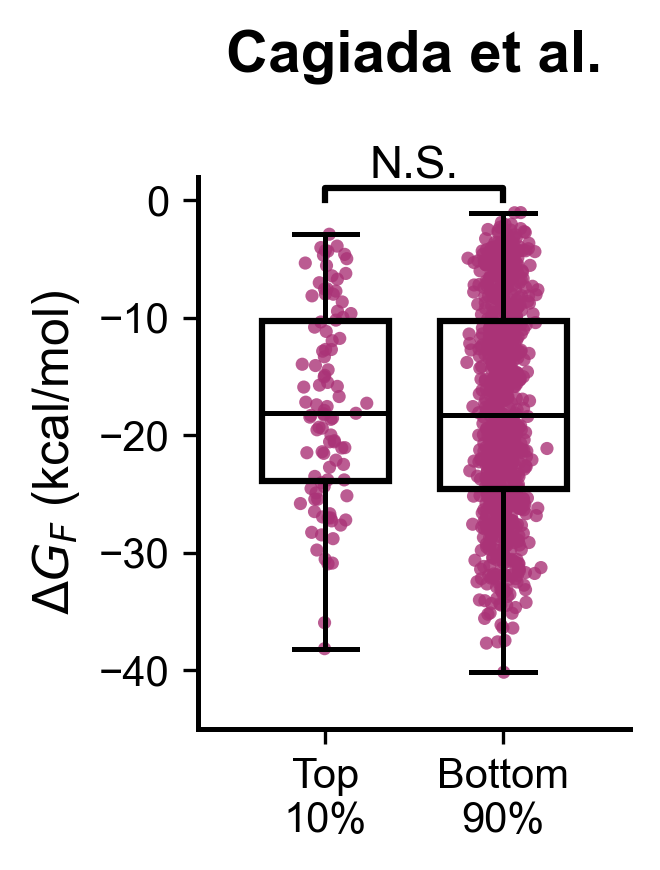

In [23]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals = [y2h_hub_vals, y2h_nothub_vals]
group_colors = ['#AA3377',    '#AA3377']

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Top\n10%", "Bottom\n90%"],
    positions=[1, 1.7],   
    widths=0.5,             
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel(r"$\Delta G_F$ (kcal/mol)", fontsize=12)
ax.set_title("Cagiada et al.", fontweight='bold')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(y2h_hub_vals.min(), y2h_nothub_vals.min())
y_max = 10
ax.set_ylim(-45, 2)     # 5% padding at bottom, 0 at top

# Place significance bracket at a fixed, nice height just above 0
bracket_y = 0  # you can adjust: -1, -3, -5 depending on taste
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")


# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

# Y2H under boxes 3–4
#ax.plot(
#    [1.0, 1.7], [-0.16, -0.16],
#    transform=trans,
#    clip_on=False,
#    color=Y2H_COLOR,
#    lw=1.5,
#)
#ax.text(
#    1.3, -0.20, "Y2H",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=Y2H_COLOR,
#)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("Supp3-G.svg")
plt.show()

In [24]:
# Only remove inf/nan — DO NOT require > 0
y2h_nothub_vals = y2h_nothub["Rosetta_best_total_score"]
y2h_hub_vals    = y2h_hubs["Rosetta_best_total_score"]

# Groups: (label, data, color)
groups = [
    ("Y2H hubs",     y2h_hub_vals,    Y2H_COLOR),
    ("Y2H non-hubs", y2h_nothub_vals, Y2H_COLOR),
]

# Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:12<00:00, 81932.87it/s]


Y2H hubs: median=-1007.04, 95% CI=(-1206.60, -819.26), n=99)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:21<00:00, 45461.60it/s]


Y2H non-hubs: median=-1008.92, 95% CI=(-1073.13, -972.13), n=883)


In [25]:
# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on Rosetta_best_total_score ===")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="greater")

print("=== Mann–Whitney U tests on Rosetta_best_total_score ===")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

=== Mann–Whitney U tests on Rosetta_best_total_score ===

Y2H hubs vs Y2H non-hubs
n(hubs) = 99, n(non-hubs) = 883
median(hubs) = -1007.04, median(non-hubs) = -1008.92
U = 43148.00, p = 0.8342
=== Mann–Whitney U tests on Rosetta_best_total_score ===

Y2H hubs vs Y2H non-hubs
n(hubs) = 99, n(non-hubs) = 883
median(hubs) = -1007.04, median(non-hubs) = -1008.92
U = 43148.00, p = 0.583


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_31870/3699507285.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


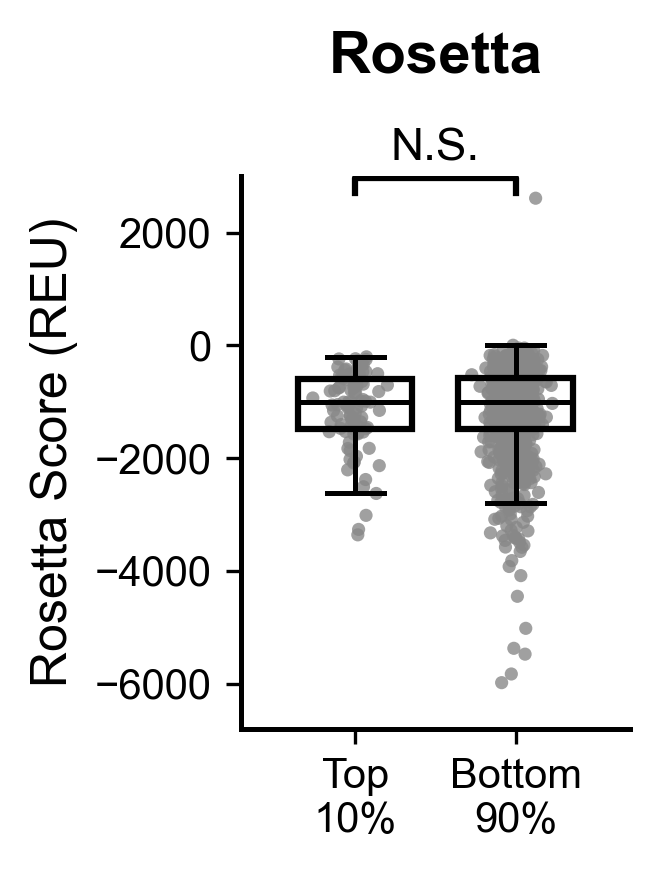

In [26]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals = [y2h_hub_vals, y2h_nothub_vals]
group_colors = ['#888888',    '#888888']

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Top\n10%", "Bottom\n90%"],
    positions=[1, 1.7],   
    widths=0.5,             
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel("Rosetta Score (REU)", fontsize=12)
ax.set_title("Rosetta", fontweight='bold')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(y2h_hub_vals.min(), y2h_nothub_vals.min())
y_max = max(y2h_hub_vals.max(), y2h_nothub_vals.max())
ax.set_ylim(-6800, 3000)

# Place significance bracket at a fixed, nice height just above 0
bracket_y = 2700  # you can adjust: -1, -3, -5 depending on taste
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")

# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

# Y2H under boxes 3–4
# Y2H under boxes 3–4
#ax.plot(
#    [1.0, 1.7], [-0.16, -0.16],
#    transform=trans,
#    clip_on=False,
#    color=Y2H_COLOR,
#    lw=1.5,
#)
#ax.text(
#    1.3, -0.20, "Y2H",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=Y2H_COLOR,
#)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("Supp3-E.svg")
plt.show()

In [27]:
# Only remove inf/nan — DO NOT require > 0
y2h_hub_vals = y2h_hubs[y2h_hubs['meltome-fit-R2'] > 0.9]["meltome-melting-point"]\
    .replace([np.inf, -np.inf], np.nan).dropna()

y2h_nothub_vals = y2h_nothub[y2h_nothub['meltome-fit-R2'] > 0.9]["meltome-melting-point"]\
    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Y2H hubs",     y2h_hub_vals,    Y2H_COLOR),
    ("Y2H non-hubs", y2h_nothub_vals, Y2H_COLOR),
]

# Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:32<00:00, 30397.27it/s]


Y2H hubs: median=49.57, 95% CI=(47.33, 50.50), n=47)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:17<00:00, 58504.26it/s]

Y2H non-hubs: median=49.75, 95% CI=(49.49, 49.97), n=467)


In [28]:
# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on meltome-melting-point ===")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="greater")

print("=== Mann–Whitney U tests on meltome-melting-point ===")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

=== Mann–Whitney U tests on meltome-melting-point ===

Y2H hubs vs Y2H non-hubs
n(hubs) = 47, n(non-hubs) = 467
median(hubs) = 49.57, median(non-hubs) = 49.75
U = 10840.00, p = 0.8902
=== Mann–Whitney U tests on meltome-melting-point ===

Y2H hubs vs Y2H non-hubs
n(hubs) = 47, n(non-hubs) = 467
median(hubs) = 49.57, median(non-hubs) = 49.75
U = 10840.00, p = 0.5553


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_31870/387391329.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


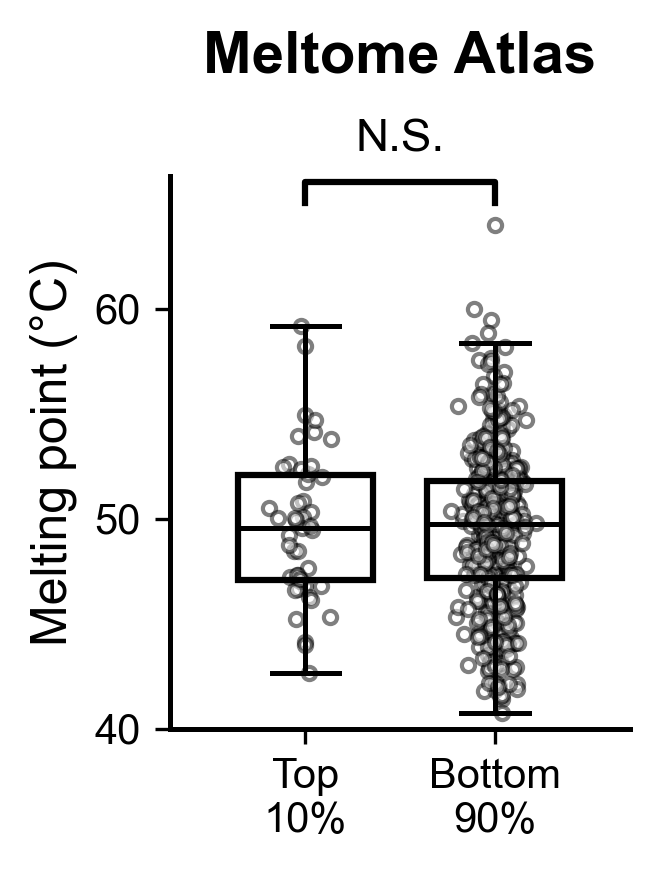

In [29]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top + 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals = [y2h_hub_vals, y2h_nothub_vals]
group_colors = ['white',    'white']

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        facecolor="white",   # inside color
        edgecolor="black",
        alpha=0.5,
        color=color,
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Top\n10%", "Bottom\n90%"],
    positions=[1, 1.7],   
    widths=0.5,             
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel("Melting point (°C)", fontsize=12)
ax.set_title("Meltome Atlas", fontweight='bold')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = 40     # a little below the real minimum
y_max = 66.3     # enough headroom for the bracket
ax.set_ylim(y_min, y_max)
ax.set_yticks([40, 50, 60])          # ← forces exactly these ticks
ax.set_yticklabels([40, 50, 60])

# Place significance bracket at a fixed, nice height just above 0
bracket_y = 65
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")


# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

# Y2H under boxes 3–4
#ax.plot(
#    [1.0, 1.7], [-0.16, -0.16],
#    transform=trans,
#    clip_on=False,
#    color=Y2H_COLOR,
#    lw=1.5,
#)
#ax.text(
#    1.3, -0.20, "Y2H",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=Y2H_COLOR,
#)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("Supp3-H.svg")
plt.show()